In [1]:
import os
import torch
import numpy as np
import pyexr  # This will be our reliable loader
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter   
import datetime

tensorboard setup

In [13]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join("logs", "engineered_unet_" + current_time)
writer = SummaryWriter(log_dir)

print(f"TensorBoard logging to: {log_dir}")

TensorBoard logging to: logs\engineered_unet_20260211-113020


In [22]:
class KOREATECH_HolographyDataset(Dataset):
    def __init__(self, root_dir, encoder):
        self.encoder = encoder
        self.img_dir = os.path.join(root_dir, "img")
        self.depth_dir = os.path.join(root_dir, "depth")
        self.amp_dir = os.path.join(root_dir, "amp")
        self.phs_dir = os.path.join(root_dir, "phs")
        
        # Get all potential indices
        all_indices = sorted([f.replace(".exr", "") for f in os.listdir(self.img_dir) if f.endswith(".exr")])
        
        # Optional: You could pre-validate files here, but let's do it on-the-fly to save time
        self.indices = all_indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        
        # 1. Engineered Input (30 channels)
        x = self.encoder.encode(os.path.join(self.img_dir, f"{i}.exr"), 
                               os.path.join(self.depth_dir, f"{i}.exr"))
        
        # 2. Corrected Target Loading
        # Load Amplitude and Phase
        amp_raw = self.encoder.load_exr(os.path.join(self.amp_dir, f"{i}.exr"))
        phs_raw = self.encoder.load_exr(os.path.join(self.phs_dir, f"{i}.exr"))
        
        # Convert to Tensors and ensure [1, 512, 512]
        # pyexr/cv2 often returns [512, 512, 3] even for grayscale EXRs
        amp = torch.from_numpy(amp_raw)
        phs = torch.from_numpy(phs_raw)

        # Fix: Take only the first channel if it's 3-channel, and remove extra dims
        if amp.ndim == 3: amp = amp[:, :, 0] 
        if phs.ndim == 3: phs = phs[:, :, 0]
        
        # Final target stack [2, 512, 512]
        y = torch.cat([amp.unsqueeze(0), phs.unsqueeze(0)], dim=0)
            
        return x, y

In [10]:
# from huggingface_hub import snapshot_download

# # This will download ONLY the phs folder into your directory
# snapshot_download(
#     repo_id="SPIN-Lab/KOREATECH-CGH-512-3.6Mu",
#     repo_type="dataset",
#     local_dir=r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu",
#     allow_patterns=["train/phs/*"]
# )
# print("Download complete!")

In [ ]:
class KOREATECH_CGH_Encoder:
    def __init__(self, res=512, pitch=3.6e-6, wavelength=638e-9):
        self.res, self.pitch, self.wavelength = res, pitch, wavelength
        f = torch.fft.fftfreq(res, d=pitch)
        self.fy, self.fx = torch.meshgrid(f, f, indexing='ij')
        term = (1.0 / self.wavelength)**2 - self.fx**2 - self.fy**2
        self.phase_kernel = 2 * np.pi * torch.sqrt(torch.clamp(term, min=0))

    def load_exr(self, path):
        # pyexr loads directly into float32 numpy arrays 
        file = pyexr.open(path)
        return file.get().astype(np.float32)

    def encode(self, img_path, depth_path):
        rgb_raw = self.load_exr(img_path)
        depth_raw = self.load_exr(depth_path)

        # Correct shape for Torch [C, H, W]
        rgb = torch.from_numpy(rgb_raw).permute(2, 0, 1) if rgb_raw.ndim == 3 else torch.from_numpy(rgb_raw).unsqueeze(0)
        depth = torch.from_numpy(depth_raw).squeeze()
        
        # Physics: 20.33mm range
        z_map = depth * 20.3336e-3 
        encoding_arg = self.phase_kernel * z_map
        freq_cos, freq_sin = torch.cos(encoding_arg), torch.sin(encoding_arg)
        
        # 8 Depth Buckets (24 Channels)
        # buckets = [rgb * ((depth >= i/8.0) & (depth < (i+1)/8.0)).float().unsqueeze(0) for i in range(8)]
            
        return torch.cat([rgb, depth.unsqueeze(0), freq_cos.unsqueeze(0), freq_sin.unsqueeze(0)], dim=0)

In [ ]:
data_root = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu"
encoder = KOREATECH_CGH_Encoder()
train_dataset = KOREATECH_HolographyDataset(os.path.join(data_root, "train"), encoder)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = KOREATECH_HolographyDataset(os.path.join(data_root, "validation"), encoder)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
print(f"Validation images found: {len(val_dataset)}")

try:
    x, y = next(iter(train_loader))
    print(f"Success Input Shape: {x.shape}, Target Shape: {y.shape}")
except Exception as e:
    print(f"Final Attempt Failed: {e}")

Validation images found: 500
Final Attempt Failed: 'KOREATECH_CGH_Encoder' object has no attribute 'phase_kernel_base'


Model architecture (U-Net)

In [17]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=30, out_channels=2):
        super(SimpleUNet, self).__init__()

        # Encoder (Downsampling)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        # Bottleneck
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(1024, 512)
        
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(512, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128)
        
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(128, 64)

        # Output Head: [Amplitude, Phase]
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder with Skip Connections
        u1 = self.up1(x5)
        u1 = torch.cat([u1, x4], dim=1)
        u1 = self.conv_up1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x3], dim=1)
        u2 = self.conv_up2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, x2], dim=1)
        u3 = self.conv_up3(u3)

        u4 = self.up4(u3)
        u4 = torch.cat([u4, x1], dim=1)
        u4 = self.conv_up4(u4)

        return self.outc(u4)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUNet(in_channels=30, out_channels=2).to(device)
print(f"Model initialized on {device}")

Model initialized on cuda


load checkpoint file

In [39]:
checkpoint_path = "unet_cgh_epoch_50.pth"
start_epoch = 0

if os.path.exists(checkpoint_path):
    # Load weights into the model instance you initialized earlier
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded checkpoint: {checkpoint_path}")
    # Set start_epoch to 50 so the loop begins at 51
    start_epoch = 50 
else:
    print("No checkpoint found. Starting from epoch 0.")

Loaded checkpoint: unet_cgh_epoch_50.pth


Training model

In [ ]:
import torch.optim as optim

# 1. Loss Function
# We use MSE to compare the predicted Amplitude/Phase with the Ground Truth
criterion = nn.MSELoss()

# 2. Optimizer
# Adam is generally best for U-Net architectures
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Learning Rate Scheduler (Optional but recommended)
# This reduces the learning rate if the loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

total_epochs = 100 

print(f"Resuming training from Epoch {start_epoch} to {total_epochs}...")

for epoch in range(start_epoch, total_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)   # [Batch, 30, 512, 512]
        targets = targets.to(device) # [Batch, 2, 512, 512]
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Log Batch Loss to TensorBoard
        global_step = epoch * len(train_loader) + batch_idx
        writer.add_scalar('Batch/Loss', loss.item(), global_step)

        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch+1}/{total_epochs}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.6f}")

    # --- END OF EPOCH LOGIC ---
    epoch_loss = running_loss / len(train_loader)
    print(f"==> Epoch {epoch+1} Complete. Average Loss: {epoch_loss:.6f}")
    
    # Log Average Epoch Loss
    writer.add_scalar('Epoch/Average_Loss', epoch_loss, epoch)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs = val_inputs.to(device)
            val_targets = val_targets.to(device)
            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_targets)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    writer.add_scalar('Epoch/Validation_Loss', avg_val_loss, epoch)
    print(f"[Validation] Epoch {epoch+1} - Avg MSE: {avg_val_loss:.6f}")
    
    # Log Visual Sample to TensorBoard
    with torch.no_grad():
        # Taking the first image in the current batch for visualization
        # Amplitude is Channel 0
        vis_amp = outputs[0, 0:1].detach().cpu() 
        writer.add_image('Visuals/Predicted_Amplitude', vis_amp, epoch)
        
        # Optional: Log Phase too (Channel 1)
        vis_phs = outputs[0, 1:2].detach().cpu()
        writer.add_image('Visuals/Predicted_Phase', vis_phs, epoch)

    # Update learning rate
    scheduler.step(epoch_loss)
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        save_name = f"unet_cgh_epoch_only_frequency_encoding_{epoch+1}.pth"
        torch.save(model.state_dict(), save_name)
        print(f"Saved checkpoint: {save_name}")

writer.close()
print("Training Finished.")

Resuming training from Epoch 50 to 100...
Epoch [51/100] Batch [0/5000] Loss: 0.003410
Epoch [51/100] Batch [10/5000] Loss: 0.003975
Epoch [51/100] Batch [20/5000] Loss: 0.003208
Epoch [51/100] Batch [30/5000] Loss: 0.002312
Epoch [51/100] Batch [40/5000] Loss: 0.002726
Epoch [51/100] Batch [50/5000] Loss: 0.003572
Epoch [51/100] Batch [60/5000] Loss: 0.003139
Epoch [51/100] Batch [70/5000] Loss: 0.003407
Epoch [51/100] Batch [80/5000] Loss: 0.003649
Epoch [51/100] Batch [90/5000] Loss: 0.003384
Epoch [51/100] Batch [100/5000] Loss: 0.002802
Epoch [51/100] Batch [110/5000] Loss: 0.003017
Epoch [51/100] Batch [120/5000] Loss: 0.002450
Epoch [51/100] Batch [130/5000] Loss: 0.003449
Epoch [51/100] Batch [140/5000] Loss: 0.003801
Epoch [51/100] Batch [150/5000] Loss: 0.003307
Epoch [51/100] Batch [160/5000] Loss: 0.002892
Epoch [51/100] Batch [170/5000] Loss: 0.002773
Epoch [51/100] Batch [180/5000] Loss: 0.002640
Epoch [51/100] Batch [190/5000] Loss: 0.003215
Epoch [51/100] Batch [200/500

Model Validation

In [ ]:
#Define Evaluation Function
# def evaluate_validation_set(model, loader, criterion):
#     model.eval()
#     total_loss = 0.0
    
#     print(f"Evaluating on {len(loader)} validation samples...")
#     with torch.no_grad():
#         for i, (inputs, targets) in enumerate(loader):
#             inputs = inputs.to(device)
#             targets = targets.to(device)
            
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             total_loss += loss.item()
            
#             if i % 50 == 0:  
#                 print(f"Processed {i}/{len(loader)}...")
                
#     avg_loss = total_loss / len(loader)
#     print(f"--- Finished ---")
#     print(f"Average Validation MSE Loss: {avg_loss:.8f}")
#     return avg_loss


# # This uses the 'model' instance currently in memory (Epoch 100 weights)
# avg_val_loss = evaluate_validation_set(model, val_loader, criterion)


# writer.add_scalar('Evaluation/Avg_Val_Loss', avg_val_loss, 100)

Model Prediction

In [ ]:
model_path = r"C:\Users\Kai Kumano\workspace\CGH-depth\weight\v1\unet_cgh_epoch_only_frequency_encoding_100.pth"
data_root = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu"
save_dir = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions"
os.makedirs(save_dir, exist_ok=True)

# 2. LOAD MODEL (30-Channel Architecture)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the 30-channel U-Net
model = SimpleUNet(in_channels=30, out_channels=2).to(device)

# Load the trained weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 3. INITIALIZE ENCODER
# Ensure this matches the parameters used during training
encoder = KOREATECH_CGH_Encoder(res=512, pitch=3.6e-6, wavelength=638e-9)

# 4. SELECT TEST SAMPLE
test_index = "5799" 
test_img_path = os.path.join(data_root, "test", "img", f"{test_index}.exr")
test_depth_path = os.path.join(data_root, "test", "depth", f"{test_index}.exr")

# test_img_path = os.path.join(data_root, "test", "img", "honney_rgb.exr")
# test_depth_path = os.path.join(data_root, "test", "depth", "honney_dep.exr")

In [28]:
def predict_and_save_engineered():
    # A. Engineering the 30-channel input
    # This automatically handles RGB-D loading and diffraction math
    x_feature = encoder.encode(test_img_path, test_depth_path)
    
    # Add batch dimension and move to device: [1, 30, 512, 512]
    x_input = x_feature.unsqueeze(0).to(device)

    # B. Inference
    with torch.no_grad():
        output = model(x_input).squeeze(0).cpu().numpy() # [2, 512, 512]
    
    pred_amp = output[0]
    pred_phs = output[1]

    # C. Save to File (.exr)
    # Channel 0: Amplitude, Channel 1: Phase
    output_to_save = np.zeros((512, 512, 3), dtype=np.float32)
    output_to_save[:, :, 0] = pred_amp
    output_to_save[:, :, 1] = pred_phs

    save_path = os.path.join(save_dir, f"engineered_pred_{test_index}.exr")
    pyexr.write(save_path, output_to_save)

    amp_save_path = os.path.join(save_dir, f"prediction_{test_index}_amp.exr")
    pyexr.write(amp_save_path, pred_amp) 

    phs_save_path = os.path.join(save_dir, f"prediction_{test_index}_phs.exr")
    pyexr.write(phs_save_path, pred_phs)

#     plt.imsave(os.path.join(save_dir, f"prediction_{test_index}_amp.png"), 
#            pred_amp, cmap='gray')
#     plt.imsave(os.path.join(save_dir, f"prediction_{test_index}_phs.png"), 
#            pred_phs, cmap='hsv', vmin=-np.pi, vmax=np.pi)

#     print(f"PNG files saved to: {save_dir}")
    print(f"Success! Engineered prediction saved to: {save_path}")

    return pred_amp, pred_phs

Success! Engineered prediction saved to: C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions\engineered_pred_5799.exr


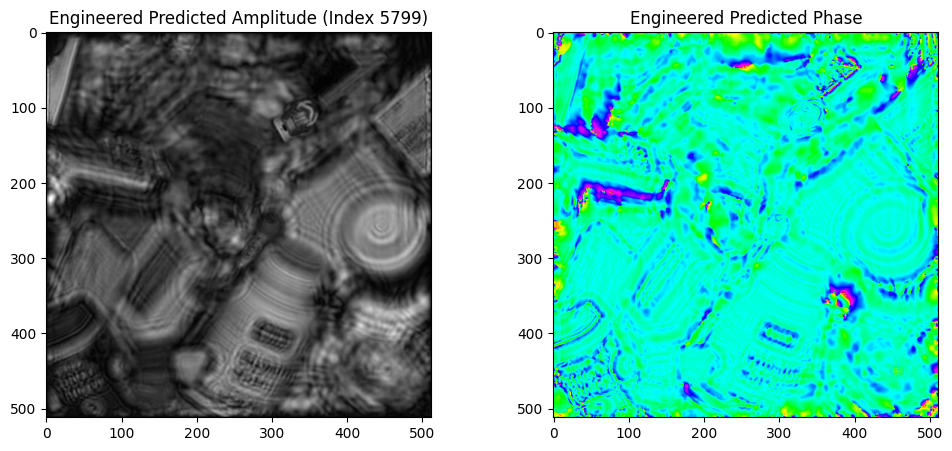

In [29]:
p_amp, p_phs = predict_and_save_engineered()

# 6. VISUALIZE IN JUPYTER
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(p_amp, cmap='gray')
axes[0].set_title(f"Engineered Predicted Amplitude (Index {test_index})")
axes[1].imshow(p_phs, cmap='hsv')
axes[1].set_title("Engineered Predicted Phase")
plt.show()

Visualize the EXR file

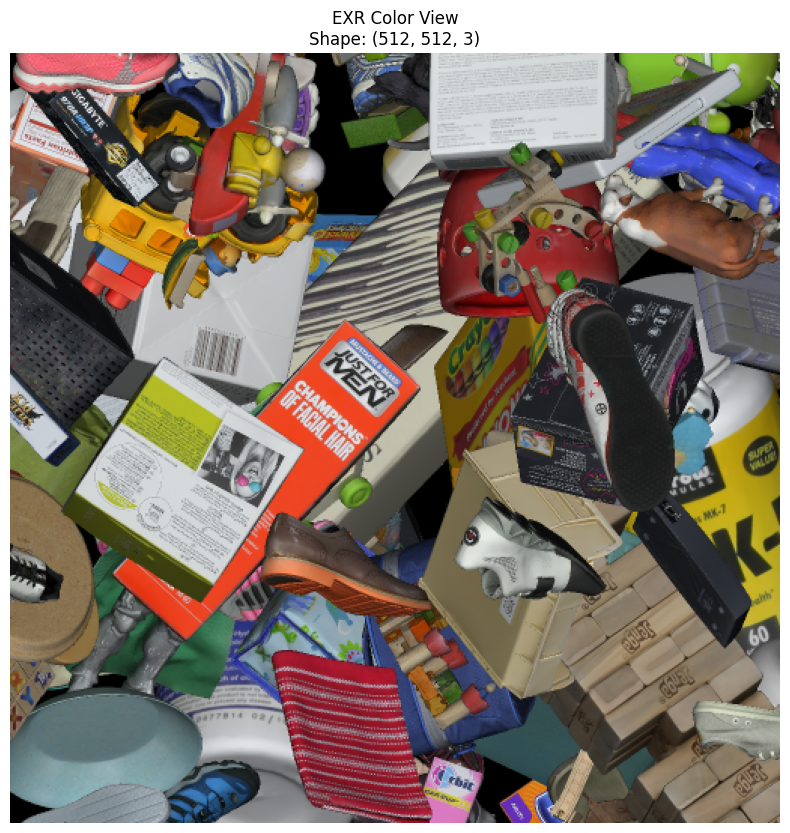

In [66]:
import pyexr
import numpy as np
import matplotlib.pyplot as plt

def show_exr_color(file_path, title="EXR Color View"):
    """
    EXRファイルをRGBカラー画像として表示する。
    """
    # 1. データのロード [H, W, C]
    data = pyexr.open(file_path).get().astype(np.float32)
    
    # 2. 形状の確認と調整
    if data.ndim == 3 and data.shape[2] >= 3:
        # 最初の3チャンネルをRGBとして取得
        display_img = data[:, :, :3]
    else:
        print("警告: このファイルは3チャンネル（RGB）を持っていないようです。")
        display_img = data

    # 3. 視覚化のための正規化 (0.0 - 1.0 に収める)
    img_min = display_img.min()
    img_max = display_img.max()
    
    if img_max > img_min:
        normalized = (display_img - img_min) / (img_max - img_min)
    else:
        normalized = display_img


    # 5. 表示
    plt.figure(figsize=(10, 10))
    plt.imshow(normalized)
    plt.title(f"{title}\nShape: {data.shape}")
    plt.axis('off')
    plt.show()

# Example Usage:
show_exr_color(r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu\test\img\5500.exr")